In [46]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

class MembershipInferenceAttack:
    """
    A class to represent a membership inference attack.
    
    This class is used to perform membership inference attacks on machine learning models.
    It can be extended to implement specific attack strategies.
    """
    
    def __init__(self, target_model, num_classes= 4):
        """
        Initializes the MembershipInferenceAttack with a given model.
        
        :param model: The machine learning model to attack.
        """
        self.target_model = target_model
        self.num_classes = num_classes

    def extract_features(self, data, labels):
        predictions = self.target_model.predict(data, verbose=0)
        
        features = []
        
        for i, (pred, true_label) in enumerate(zip(predictions, labels)):
            # Flatten predictions for pixel-wise analysis
            pred_flat = pred.reshape(-1, self.num_classes)
            true_flat = true_label.flatten() if len(true_label.shape) > 1 else true_label.reshape(-1)
            
            # Feature 1: Maximum confidence (averaged over all pixels)
            max_confidence = np.mean(np.max(pred_flat, axis=1))
            
            # Feature 2: Entropy (measure of uncertainty)
            entropy = -np.mean(np.sum(pred_flat * np.log(pred_flat + 1e-8), axis=1))
            
            # Feature 3: Cross-entropy loss
            ce_loss = -np.mean(np.sum(tf.one_hot(true_flat, self.num_classes) * np.log(pred_flat + 1e-8), axis=1))
            
            # Feature 4: Prediction accuracy (pixel-wise)
            pred_labels = np.argmax(pred_flat, axis=1)
            accuracy = np.mean(pred_labels == true_flat)
            
            # Feature 5: Top-2 confidence gap
            sorted_probs = np.sort(pred_flat, axis=1)
            confidence_gap = np.mean(sorted_probs[:, -1] - sorted_probs[:, -2])
            
            # Feature 6: Variance of predictions
            pred_variance = np.var(pred_flat, axis=1).mean()
            
            # Feature 7: Mean probability of true class
            true_class_prob = np.mean([pred_flat[j, true_flat[j]] for j in range(len(true_flat))])
            
            features.append([
                max_confidence, entropy, ce_loss, accuracy, 
                confidence_gap, pred_variance, true_class_prob
            ])
        
        return np.array(features)
    
    def prepare_attack_dataset(self, member_data, member_labels, non_member_data, non_member_labels):
        """
        Prepare dataset for training the attack model
        """
        print("Extracting features from member data...")
        member_features = self.extract_features(member_data, member_labels)
        member_labels_binary = np.ones(len(member_features))  # 1 = member
        
        print("Extracting features from non-member data...")
        non_member_features = self.extract_features(non_member_data, non_member_labels)
        non_member_labels_binary = np.zeros(len(non_member_features))  # 0 = non-member
        
        # Combine datasets
        X = np.vstack([member_features, non_member_features])
        y = np.hstack([member_labels_binary, non_member_labels_binary])
        
        return X, y
    
    def train_attack_model(self, X, y, test_size=0.3):
        """
        Train the attack model to predict membership
        """
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
        
        # Use Random Forest as attack model (simple and effective)
        self.attack_model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.attack_model.fit(X_train, y_train)
        
        # Evaluate attack performance
        y_pred = self.attack_model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        print(f"Attack Model Performance:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        
        # Feature importance
        feature_names = ['Max Confidence', 'Entropy', 'CE Loss', 'Accuracy', 
                        'Confidence Gap', 'Pred Variance', 'True Class Prob']
        
        importance = self.attack_model.feature_importances_
        for name, imp in zip(feature_names, importance):
            print(f"{name}: {imp:.4f}")
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'feature_importance': dict(zip(feature_names, importance))
        }

    def enhanced_attack_with_gradients(self, data, labels):
        """
        Enhanced attack using gradient information
        This exploits the model's gradient behavior for member vs non-member data
        """
        features = []
        
        for i, (sample, label) in enumerate(zip(data, labels)):
            sample_batch = np.expand_dims(sample, axis=0)
            label_batch = np.expand_dims(label, axis=0)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_batch)
                predictions = self.target_model(sample_batch, training=False)
                loss = tf.keras.losses.sparse_categorical_crossentropy(label_batch, predictions)
            
            # Get gradients
            gradients = tape.gradient(loss, sample_batch)
            
            # Extract gradient-based features
            grad_norm = tf.norm(gradients).numpy()
            grad_mean = tf.reduce_mean(tf.abs(gradients)).numpy()
            grad_std = tf.math.reduce_std(gradients).numpy()
            
            # Combine with prediction-based features
            pred_features = self.extract_features(sample_batch, label_batch)[0]
            
            enhanced_features = np.concatenate([pred_features, [grad_norm, grad_mean, grad_std]])
            features.append(enhanced_features)
        
        return np.array(features)

In [47]:
class PrivacyAnalyzer:
    """
    Analyze privacy vulnerabilities in the model
    """
    
    def __init__(self, model):
        self.model = model
    
    def analyze_overfitting_indicators(self, train_data, val_data):
        """
        Analyze overfitting which can lead to membership inference vulnerabilities
        """
        train_loss = self.model.evaluate(train_data[0], train_data[1], verbose=0)[0]
        val_loss = self.model.evaluate(val_data[0], val_data[1], verbose=0)[0]
        
        overfitting_ratio = val_loss / train_loss
        
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Overfitting Ratio: {overfitting_ratio:.4f}")
        
        if overfitting_ratio > 1.2:
            print("WARNING: Significant overfitting detected - high MIA risk!")
        elif overfitting_ratio > 1.1:
            print("CAUTION: Moderate overfitting - potential MIA risk")
        else:
            print("INFO: Low overfitting - reduced MIA risk")
        
        return overfitting_ratio
    
    def confidence_distribution_analysis(self, member_data, non_member_data):
        """
        Analyze confidence distributions between members and non-members
        """
        member_preds = self.model.predict(member_data, verbose=0)
        non_member_preds = self.model.predict(non_member_data, verbose=0)
        
        # Calculate confidence scores
        member_confidence = np.max(member_preds.reshape(-1, member_preds.shape[-1]), axis=1)
        non_member_confidence = np.max(non_member_preds.reshape(-1, non_member_preds.shape[-1]), axis=1)
        
        # Statistical analysis
        member_mean = np.mean(member_confidence)
        non_member_mean = np.mean(non_member_confidence)
        
        print(f"Member confidence mean: {member_mean:.4f}")
        print(f"Non-member confidence mean: {non_member_mean:.4f}")
        print(f"Confidence gap: {member_mean - non_member_mean:.4f}")
        
        if abs(member_mean - non_member_mean) > 0.05:
            print("WARNING: Large confidence gap detected - vulnerable to MIA!")
        
        return member_confidence, non_member_confidence

In [48]:
def plot_feature_importance(feature_importance):
    feature_names = list(feature_importance.keys())
    importances = list(feature_importance.values())
    plt.figure(figsize=(10, 6))
    plt.bar(feature_names, importances)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance in Membership Inference Attack')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def run_membership_inference_attack(target_model, train_data, test_data, shadow_data=None):
    """
    Complete MIA pipeline
    """
    print("="*50)
    print("MEMBERSHIP INFERENCE ATTACK ANALYSIS")
    print("="*50)
    
    # Initialize attack
    mia = MembershipInferenceAttack(target_model)
    
    # Use training data as members and test data as non-members
    member_data, member_labels = train_data
    non_member_data, non_member_labels = test_data
    
    # Prepare attack dataset
    X, y = mia.prepare_attack_dataset(member_data, member_labels, 
                                     non_member_data, non_member_labels)
    
    # Train attack model
    results = mia.train_attack_model(X, y)

    print(results)
    
    # Privacy analysis
    print("\n" + "="*30)
    print("PRIVACY VULNERABILITY ANALYSIS")
    print("="*30)
    
    analyzer = PrivacyAnalyzer(target_model)
    overfitting_ratio = analyzer.analyze_overfitting_indicators(train_data, test_data)
    
    print("\nConfidence Distribution Analysis:")
    member_conf, non_member_conf = analyzer.confidence_distribution_analysis(
        member_data[:100], non_member_data[:100]  # Sample for efficiency
    )
    
    # Risk assessment
    print("\n" + "="*30)
    print("RISK ASSESSMENT")
    print("="*30)
    
    attack_accuracy = results['accuracy']

    plot_feature_importance(results['feature_importance'])
    
    if attack_accuracy > 0.7:
        risk_level = "HIGH"
        print(f"🔴 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Model is vulnerable!")
    elif attack_accuracy > 0.6:
        risk_level = "MEDIUM"
        print(f"🟡 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Some vulnerability exists")
    else:
        risk_level = "LOW"
        print(f"🟢 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Model appears robust")
    
    return results, risk_level

In [49]:
from data_loader import DataLoader
data_loader = DataLoader()
image_dir = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'
images, labels = data_loader.load_images_label_pairs(image_dir, label_dir, step=1, step_size=2500, add_noise=True)
if images is None or labels is None:
    raise ValueError("Images and labels must be loaded before running the attack.")

Images count: 27431


In [ ]:
from privacy_preserving_unet_model import PrivacyPreservingUNet

target_model = PrivacyPreservingUNet.load_model('privacy_preserving_unet_medium.h5')

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

run_membership_inference_attack(target_model, (img_train, label_train), (img_test, label_test))

MEMBERSHIP INFERENCE ATTACK ANALYSIS
Extracting features from member data...
Extracting features from non-member data...
Attack Model Performance:
Accuracy: 0.7973
Precision: 0.8202
Recall: 0.9642
Max Confidence: 0.1447
Entropy: 0.1393
CE Loss: 0.1518
Accuracy: 0.1195
Confidence Gap: 0.1546
Pred Variance: 0.1426
True Class Prob: 0.1476
{'accuracy': 0.7973333333333333, 'precision': 0.8201936376210235, 'recall': 0.9642276422764228, 'feature_importance': {'Max Confidence': 0.1446556999738355, 'Entropy': 0.1392527606522766, 'CE Loss': 0.15178648617123203, 'Accuracy': 0.11946856783623774, 'Confidence Gap': 0.154628847884468, 'Pred Variance': 0.14264547833586028, 'True Class Prob': 0.14756215914608992}}

PRIVACY VULNERABILITY ANALYSIS
Training Loss: 0.0247
Validation Loss: 0.0255
Overfitting Ratio: 1.0338
INFO: Low overfitting - reduced MIA risk

Confidence Distribution Analysis:
Member confidence mean: 0.9917
Non-member confidence mean: 0.9920
Confidence gap: -0.0002

RISK ASSESSMENT


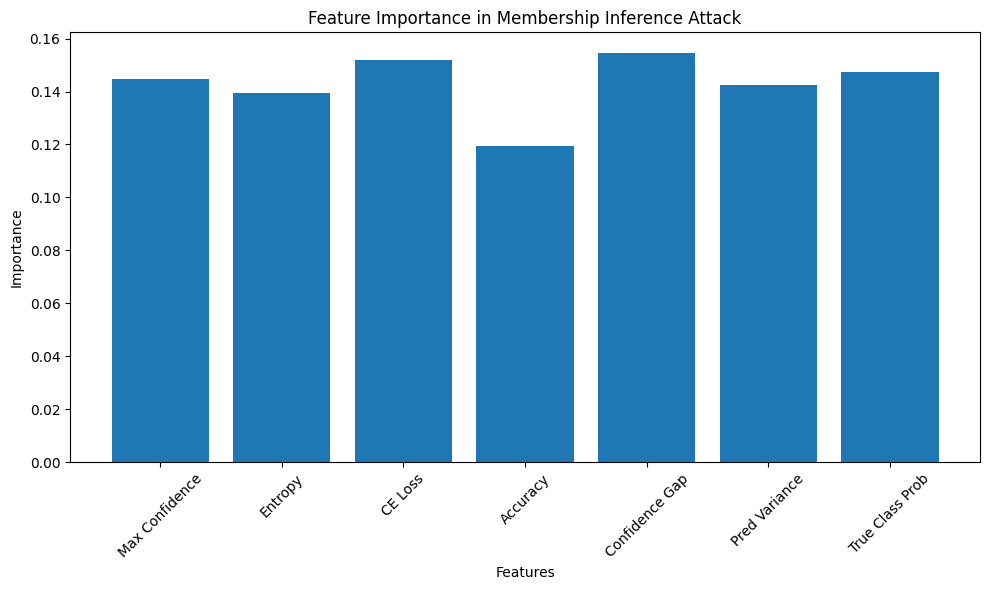

🔴 HIGH RISK: Attack accuracy 0.797 - Model is vulnerable!


({'accuracy': 0.7973333333333333,
  'precision': 0.8201936376210235,
  'recall': 0.9642276422764228,
  'feature_importance': {'Max Confidence': 0.1446556999738355,
   'Entropy': 0.1392527606522766,
   'CE Loss': 0.15178648617123203,
   'Accuracy': 0.11946856783623774,
   'Confidence Gap': 0.154628847884468,
   'Pred Variance': 0.14264547833586028,
   'True Class Prob': 0.14756215914608992}},
 'HIGH')

In [ ]:
from privacy_preserving_unet_model import PrivacyPreservingUNet

target_model = PrivacyPreservingUNet.load_model('privacy_preserving_unet_medium_5.h5')

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

run_membership_inference_attack(target_model, (img_train, label_train), (img_test, label_test))